# Код обработки и построения графиков

In [1]:
import glob
import re

import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# обрабатываем записи

tosya_files = glob.glob('childes/Tosya/*.txt')
yasha_files = glob.glob('childes/Yasha/*.txt')
super_df = pd.DataFrame(
    columns=[
        'child',
        'speaker',
        'text',
        '%flo',
        '%mor',
        'filename',
        'months'
    ]
)

for filename in list(zip(['Tosya'] * len(tosya_files), tosya_files)) + list(zip(['Yasha'] * len(yasha_files), yasha_files)):
    with open(filename[1], encoding='utf-8') as file:
        text = file.read()

    text = text.replace('\n\t', ' ').split('\n')

    date = re.sub(r'\D', '', filename[1])
    months = int(date[0]) * 12 + int(date[1:3])

    text_grouped_layers = [{'child':filename[0], 'filename':filename[1], 'months':months}]
    for l in text:
        if l[:6] == '%flo:\t':
            text_grouped_layers[-1]['%flo'] = l[6:]
        elif l[:6] == '%mor:\t':
            text_grouped_layers[-1]['%mor'] = l[6:]
        else:
            if 'speaker' in text_grouped_layers[-1]:
                text_grouped_layers.append({'child':filename[0], 'filename':filename[1], 'months':months})
            text_grouped_layers[-1]['speaker'] = l.split(':')[0]
            text_grouped_layers[-1]['text'] = l[6:]

    text_df = pd.DataFrame(text_grouped_layers)
    super_df = pd.concat((super_df, text_df))

super_df['text'] = super_df['text'].str.replace('\x15.+\x15', '', regex=True)
super_df = super_df.reset_index()

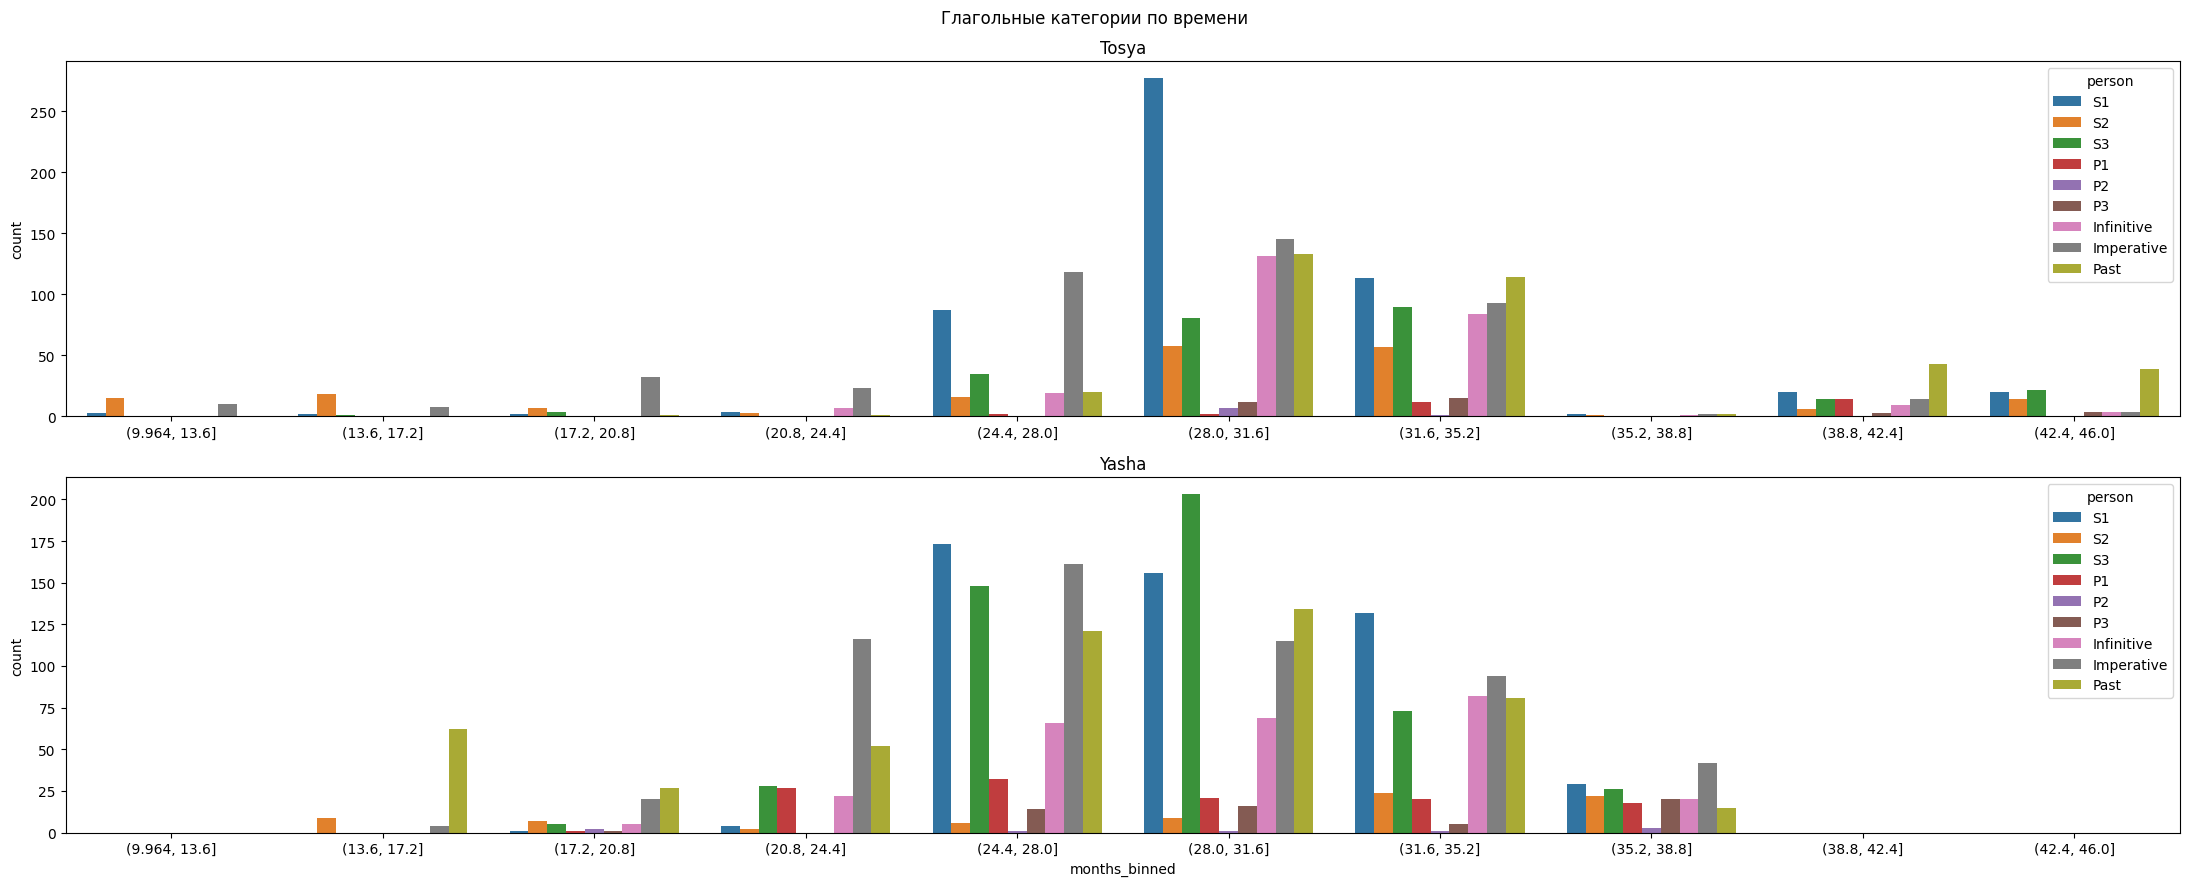

In [3]:
# график всех глагольных категорий

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(22,9), layout='tight')
fig.suptitle('Глагольные категории по времени')

palette_dict = {
    'S1': '#1f77b4',
    'S2': '#ff7f0e',
    'S3': '#2ca02c',
    'P1': '#d62728',
    'P2': '#9467bd',
    'P3': '#8c564b',
    'Infinitive': '#e377c2',
    'Imperative': '#7f7f7f',
    'Past': '#bcbd22',
}

verbs = super_df[((super_df['speaker'] == '*CHI') | (super_df['speaker'] == '*CHI1')) & (super_df['%mor'].str.contains(r'verb'))]
verb_extracted = (
    verbs['%mor']
    .str.extractall(r'(verb.+?) ')
    .rename({0:'verb'}, axis=1)
)
verb_extracted.index = verb_extracted.index.droplevel('match')
verbs = pd.merge(verbs, verb_extracted, how='right', right_index=True, left_index=True)
verbs = verbs[
    ~(
        verbs['verb'].str.contains(r'verb\|нет-')
    )
]

verbs['person'] = verbs['verb']
verbs['person'] = verbs['person'].where(~((verbs['person'].str.contains('Perf-Imp')) | (verbs['person'].str.contains('Imp-Imp'))), 'Imperative')
verbs['person'] = verbs['person'].where(~((verbs['person'].str.contains('Perf-Imp')) | (verbs['person'].str.contains('Imp-Imp'))), 'Imperative')
verbs['person'] = verbs['person'].where(~(verbs['person'].str.contains('Past')), 'Past')
verbs['person'] = verbs['person'].where(~(verbs['person'].str.contains('Inf')), 'Infinitive')
verbs['person'] = verbs['person'].where(~(verbs['person'].str.contains('Part')), 'Participle')
verbs = verbs.drop(verbs[verbs['person'].str.split('-').str[-1] == 'S'].index)
verbs['person'] = verbs['person'].str.split('-').str[-1]

verbs['months_binned'] = pd.cut(verbs['months'], bins=10)
ax1.set_title('Tosya')
sns.countplot(verbs[verbs['child'] == 'Tosya'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax1)
ax1.set_xlabel('')

ax2.set_title('Yasha')
sns.countplot(verbs[verbs['child'] == 'Yasha'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax2)

plt.show()

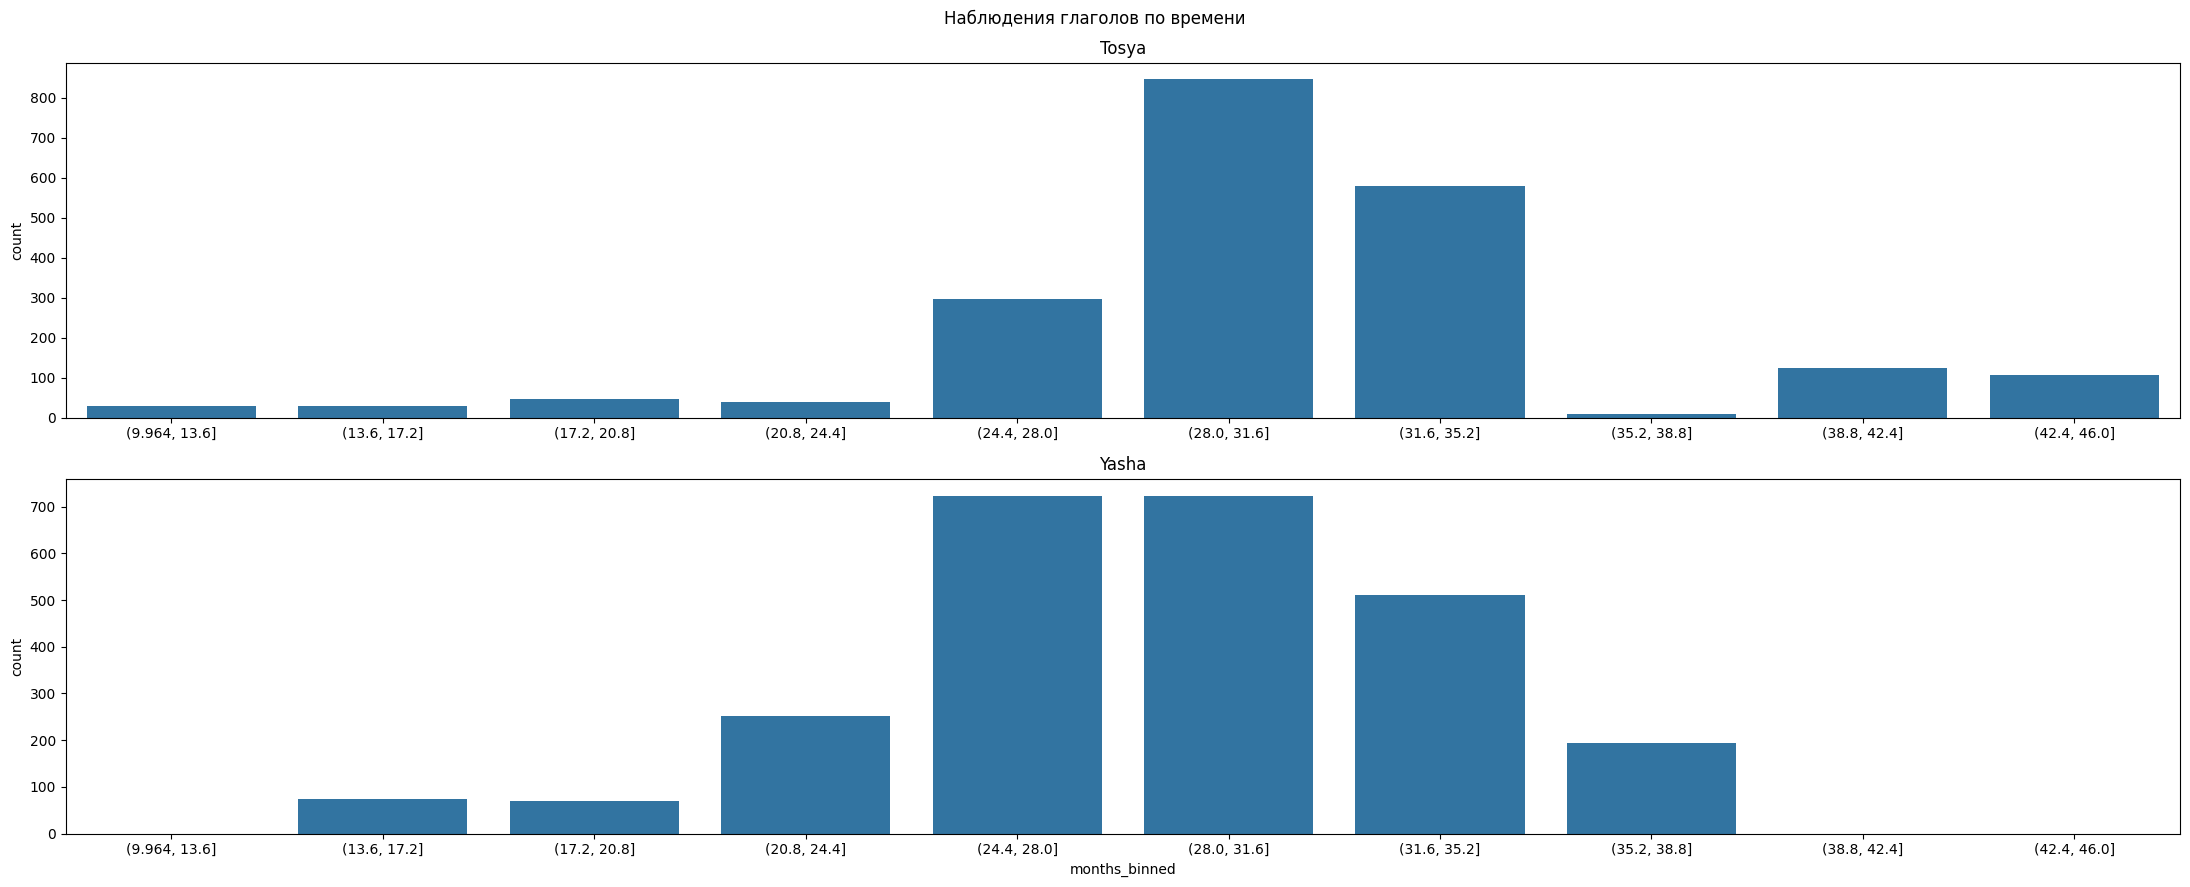

In [4]:
# количество наблюдений

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(22,9), layout='tight')
fig.suptitle('Наблюдения глаголов по времени')

ax1.set_title('Tosya')
sns.countplot(verbs[verbs['child'] == 'Tosya'], x='months_binned', ax=ax1)
ax1.set_xlabel('')

ax2.set_title('Yasha')
sns.countplot(verbs[verbs['child'] == 'Yasha'], x='months_binned', ax=ax2)

plt.show()

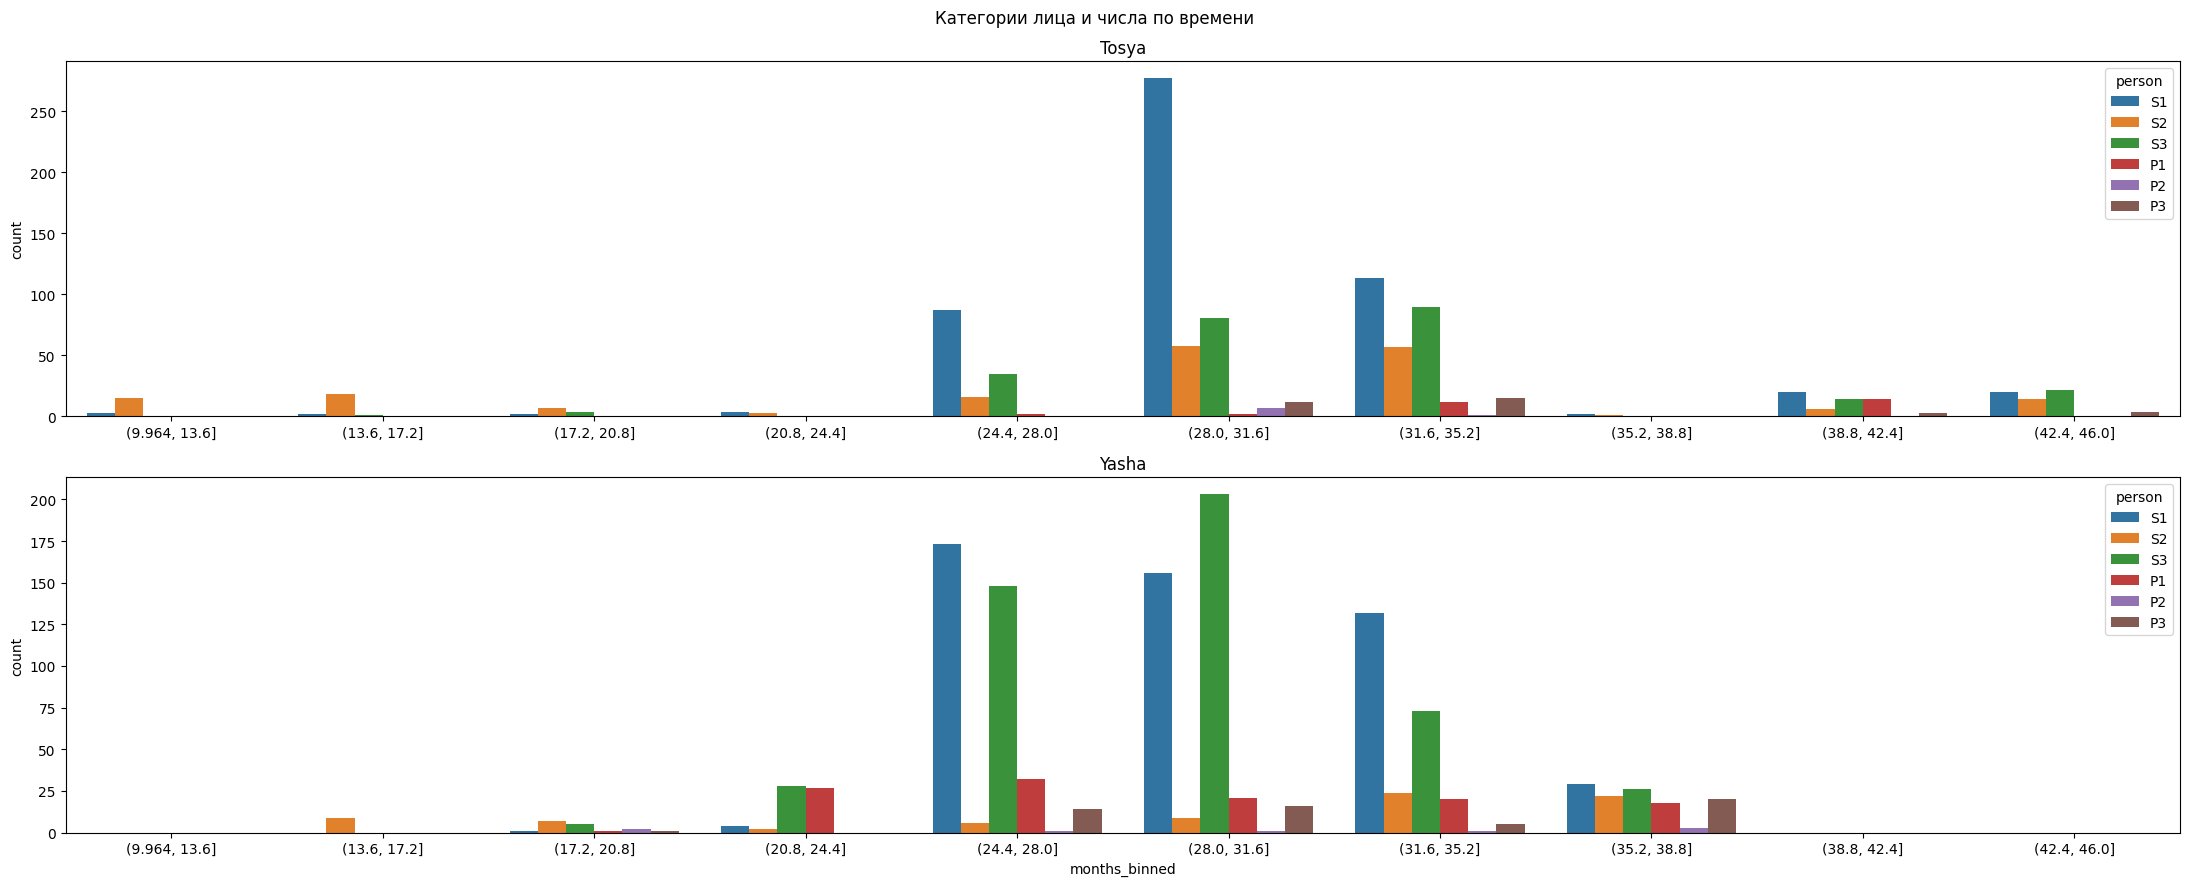

In [5]:
# категории лица и числа у финитных глаголов наст. и буд. времен

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(22,9), layout='tight')
fig.suptitle('Категории лица и числа по времени')

palette_dict = {
    'S1': '#1f77b4',
    'S2': '#ff7f0e',
    'S3': '#2ca02c',
    'P1': '#d62728',
    'P2': '#9467bd',
    'P3': '#8c564b',
}

person_number = verbs[(verbs['person'] != 'Infinitive') & (verbs['person'] != 'Imperative') & (verbs['person'] != 'Past')]

ax1.set_title('Tosya')
sns.countplot(person_number[person_number['child'] == 'Tosya'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax1)
ax1.set_xlabel('')

ax2.set_title('Yasha')
sns.countplot(person_number[person_number['child'] == 'Yasha'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax2)

plt.show()

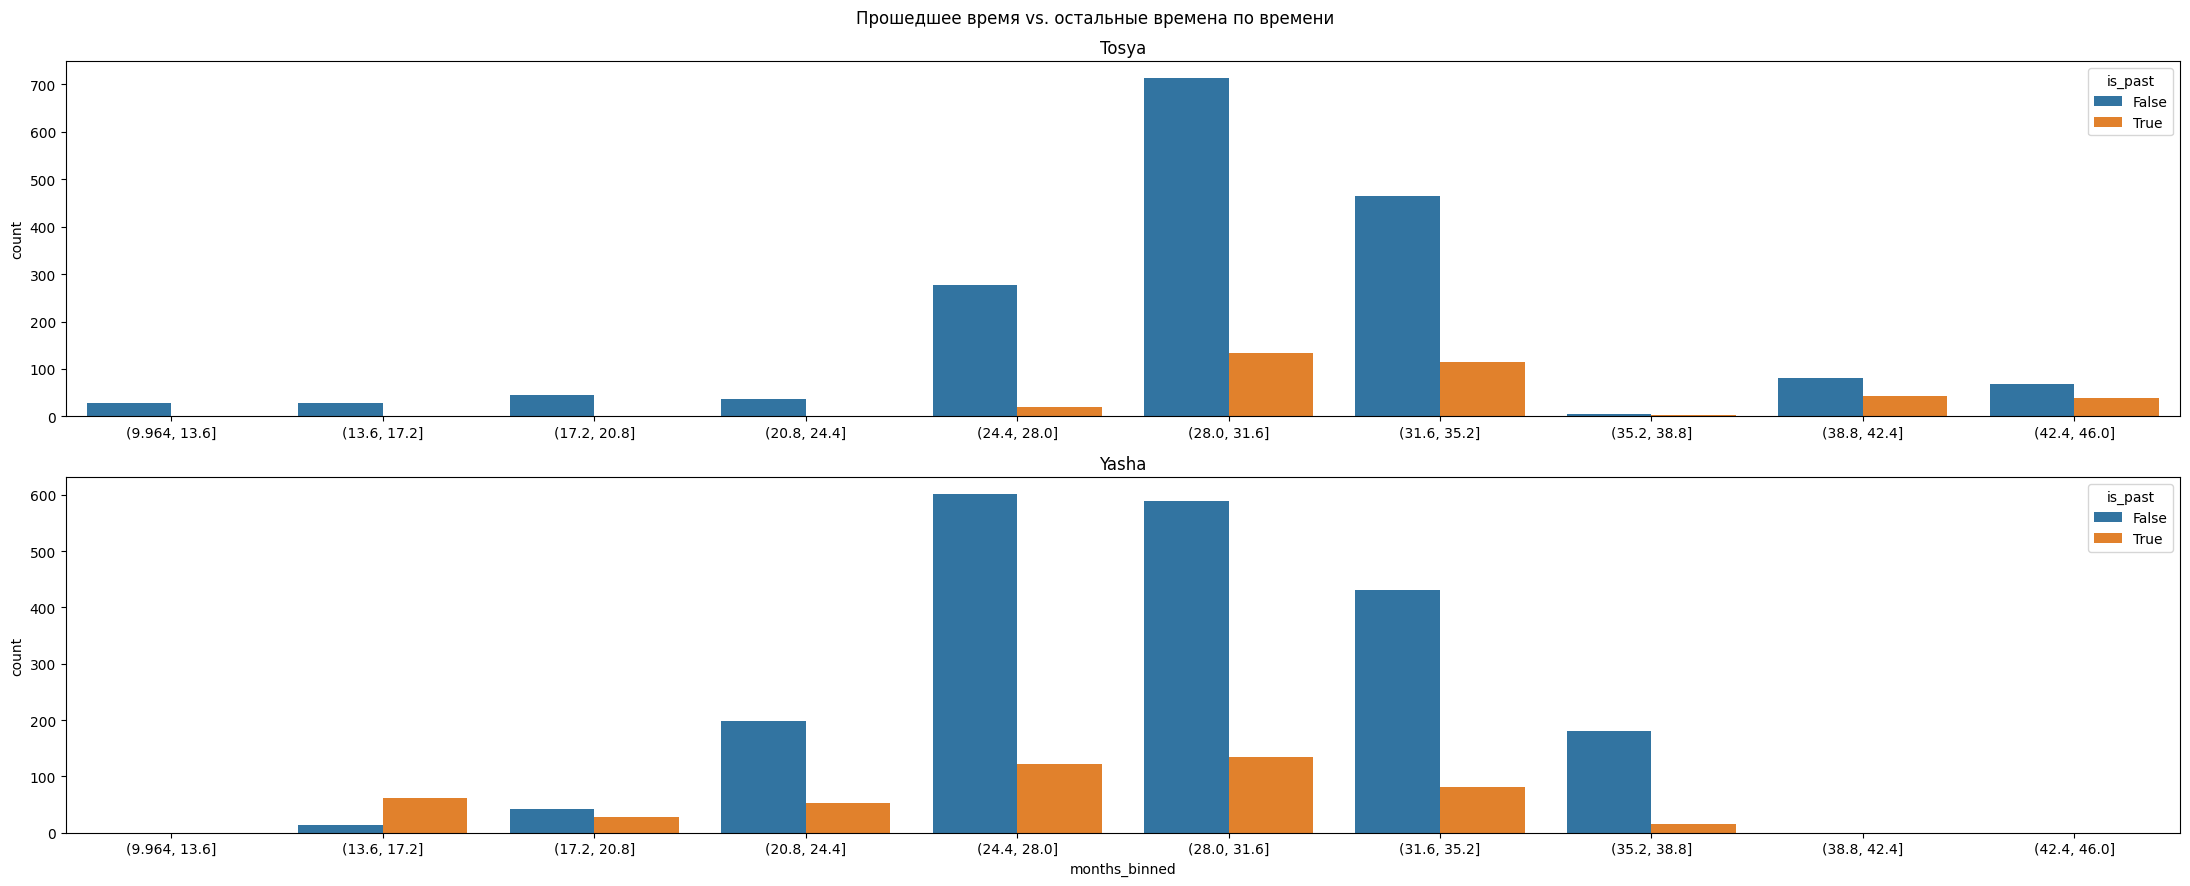

In [6]:
# прошедшее время vs. остальные времена

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(22,9), layout='tight')
fig.suptitle('Прошедшее время vs. остальные времена по времени')

verbs['is_past'] = verbs['person'].apply(lambda x: True if x =='Past' else False)

ax1.set_title('Tosya')
sns.countplot(verbs[verbs['child'] == 'Tosya'], x='months_binned', hue='is_past', ax=ax1)
ax1.set_xlabel('')

ax2.set_title('Yasha')
sns.countplot(verbs[verbs['child'] == 'Yasha'], x='months_binned', hue='is_past', ax=ax2)

plt.show()

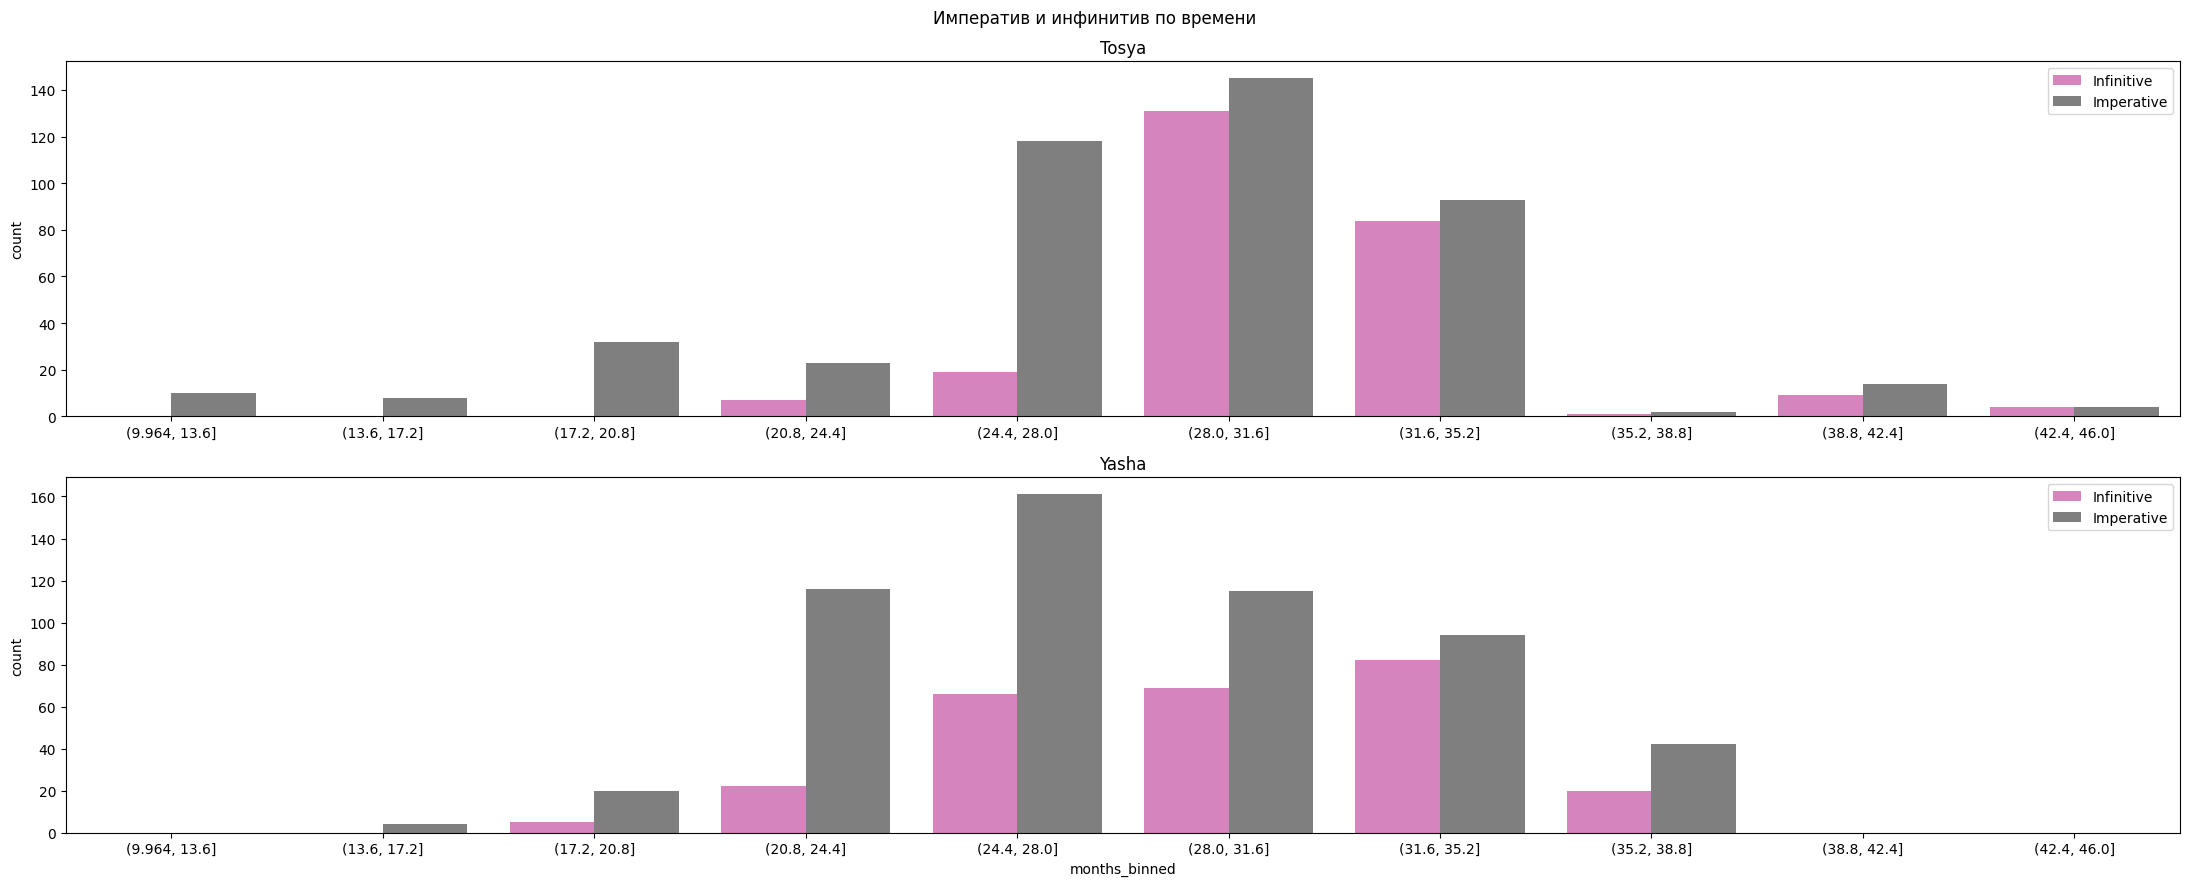

In [7]:
# императив vs инфинитив

fig, (ax1, ax2) = plt.subplots(nrows=2, ncols=1, figsize=(22,9), layout='tight')
fig.suptitle('Императив и инфинитив по времени')

palette_dict = {
    'Infinitive': '#e377c2',
    'Imperative': '#7f7f7f',
}

inf_imp = verbs[(verbs['person'] == 'Infinitive') | (verbs['person'] == 'Imperative')]

ax1.set_title('Tosya')
sns.countplot(inf_imp[inf_imp['child'] == 'Tosya'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax1)
ax1.set_xlabel('')
ax1.get_legend().set_title(None)

ax2.set_title('Yasha')
sns.countplot(inf_imp[inf_imp['child'] == 'Yasha'], x='months_binned', hue='person', palette=palette_dict, hue_order=palette_dict.keys(), ax=ax2)
ax2.get_legend().set_title(None)

plt.show()

## Бонус: падеж
В проект не включено, но почему бы не посмотреть

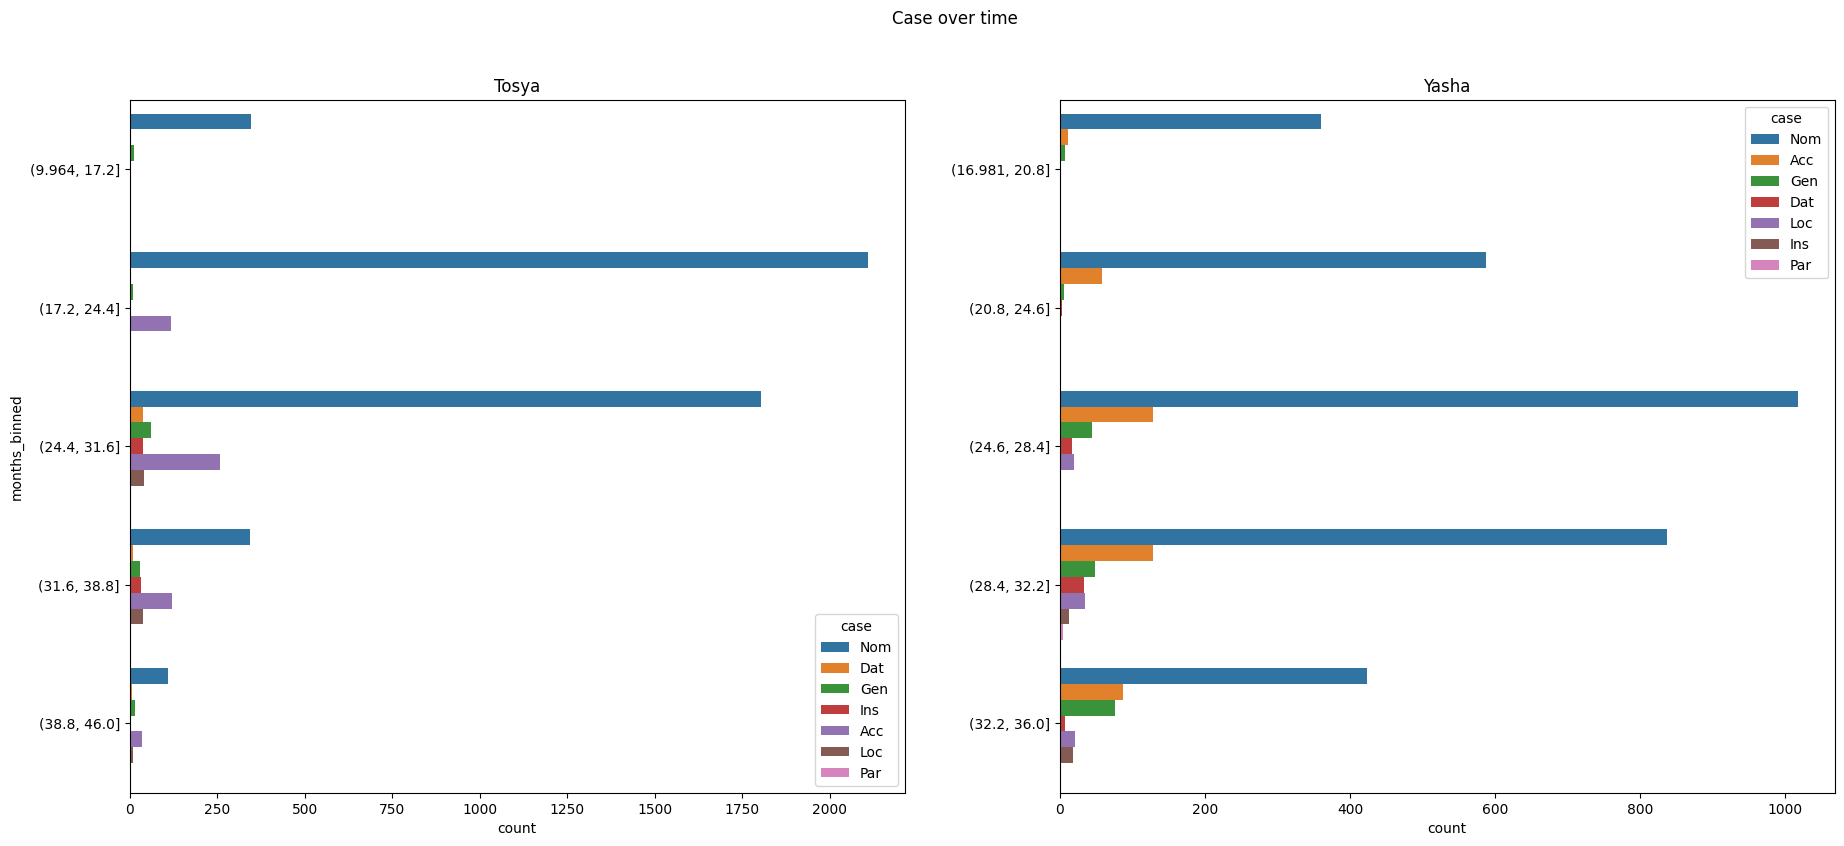

In [8]:
# падеж

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(22,9))
fig.suptitle('Case over time')


nouns = super_df[((super_df['speaker'] == '*CHI') | (super_df['speaker'] == '*CHI1')) & (super_df['%mor'].str.contains(r'noun')) & (super_df['child'] == 'Tosya')]
noun_extracted = (
    nouns['%mor']
    .str.extractall(r'(noun.+?) ')
    .rename({0:'noun'}, axis=1)
)
noun_extracted.index = noun_extracted.index.droplevel('match')
nouns = pd.merge(nouns, noun_extracted, how='right', right_index=True, left_index=True)

nouns['case'] = nouns['noun'].str.split('-').str[-1]
nouns = nouns[~nouns['case'].str.contains(r'\|')]

nouns['months_binned'] = pd.cut(nouns['months'], bins=5)
ax1.set_title('Tosya')
sns.countplot(nouns, y='months_binned', hue='case', ax=ax1)


nouns = super_df[(super_df['speaker'] == '*CHI') & (super_df['%mor'].str.contains(r'noun')) & (super_df['child'] == 'Yasha')]
noun_extracted = (
    nouns['%mor']
    .str.extractall(r'(noun.+?) ')
    .rename({0:'noun'}, axis=1)
)
noun_extracted.index = noun_extracted.index.droplevel('match')
nouns = pd.merge(nouns, noun_extracted, how='right', right_index=True, left_index=True)

nouns['case'] = nouns['noun'].str.split('-').str[-1]
nouns = nouns[~nouns['case'].str.contains(r'\|')]

nouns['months_binned'] = pd.cut(nouns['months'], bins=5)
ax2.set_title('Yasha')
sns.countplot(nouns, y='months_binned', hue='case', ax=ax2)
ax2.set_ylabel('')

plt.show()

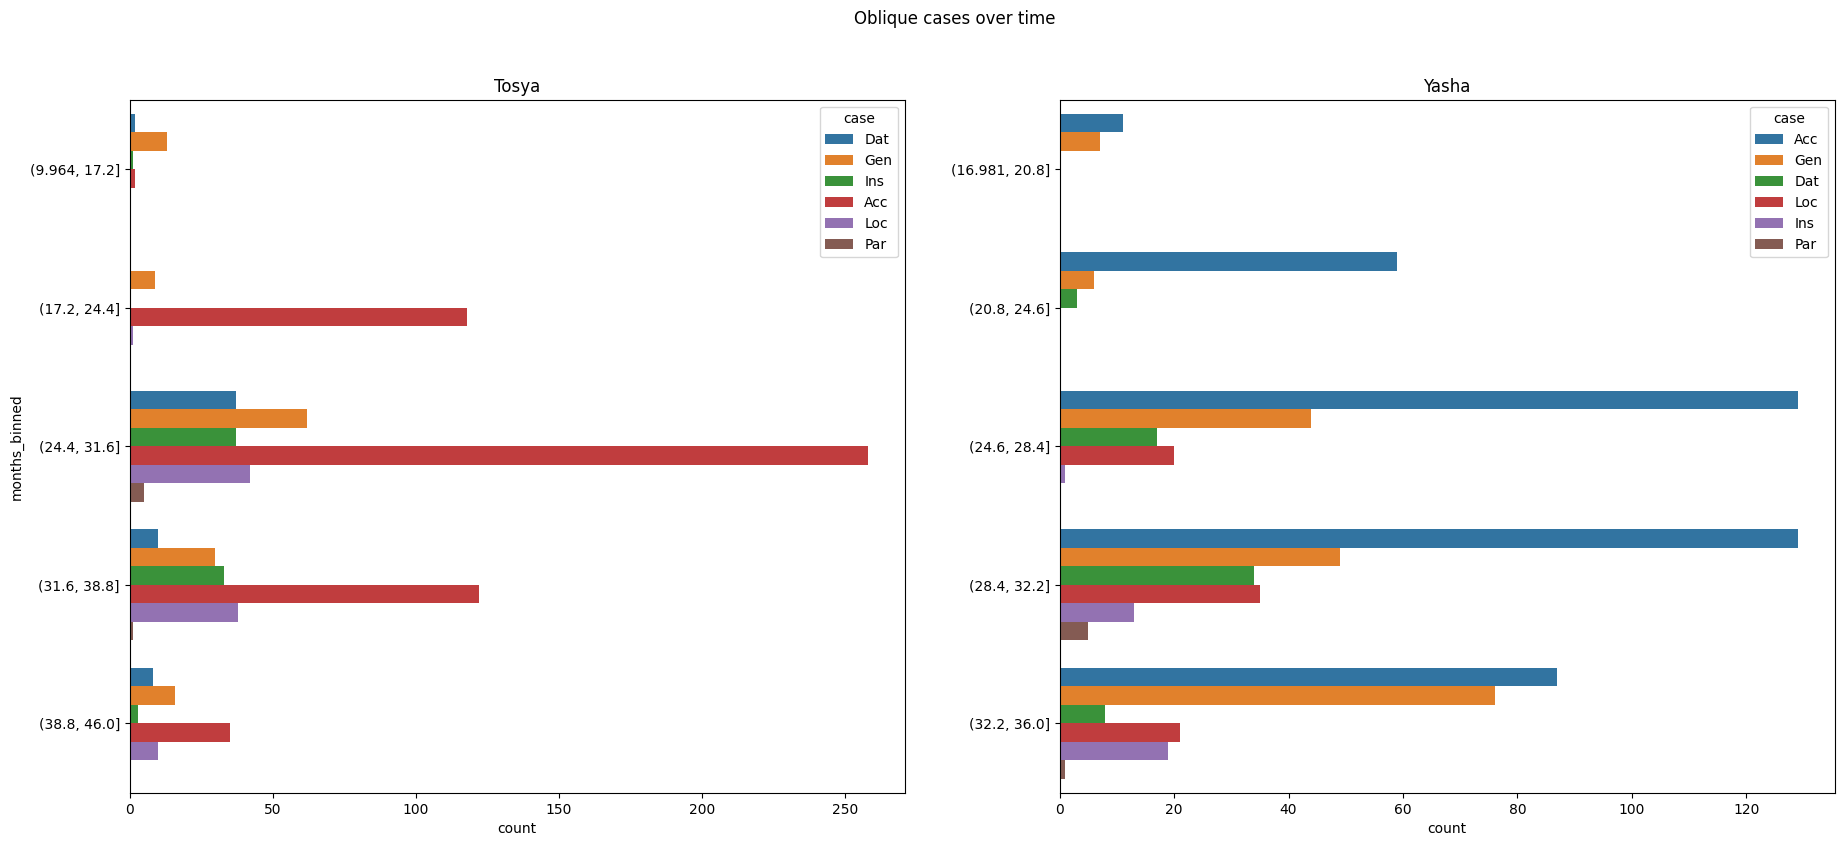

In [9]:
# косвенные падежи

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(22,9))
fig.suptitle('Oblique cases over time')


nouns = super_df[((super_df['speaker'] == '*CHI') | (super_df['speaker'] == '*CHI1')) & (super_df['%mor'].str.contains(r'noun')) & (super_df['child'] == 'Tosya')]
noun_extracted = (
    nouns['%mor']
    .str.extractall(r'(noun.+?) ')
    .rename({0:'noun'}, axis=1)
)
noun_extracted.index = noun_extracted.index.droplevel('match')
nouns = pd.merge(nouns, noun_extracted, how='right', right_index=True, left_index=True)

nouns['case'] = nouns['noun'].str.split('-').str[-1]
nouns = nouns[~nouns['case'].str.contains(r'\|')]
nouns = nouns[nouns['case'] != 'Nom']

nouns['months_binned'] = pd.cut(nouns['months'], bins=5)
ax1.set_title('Tosya')
sns.countplot(nouns, y='months_binned', hue='case', ax=ax1)


nouns = super_df[(super_df['speaker'] == '*CHI') & (super_df['%mor'].str.contains(r'noun')) & (super_df['child'] == 'Yasha')]
noun_extracted = (
    nouns['%mor']
    .str.extractall(r'(noun.+?) ')
    .rename({0:'noun'}, axis=1)
)
noun_extracted.index = noun_extracted.index.droplevel('match')
nouns = pd.merge(nouns, noun_extracted, how='right', right_index=True, left_index=True)

nouns['case'] = nouns['noun'].str.split('-').str[-1]
nouns = nouns[~nouns['case'].str.contains(r'\|')]
nouns = nouns[nouns['case'] != 'Nom']

nouns['months_binned'] = pd.cut(nouns['months'], bins=5)
ax2.set_title('Yasha')
sns.countplot(nouns, y='months_binned', hue='case', ax=ax2)
ax2.set_ylabel('')

plt.show()